# Chapter 03: Vector Calculus

**Source orientation:** PDF pages 26-36 of *Mathematical Foundations of Geometric Deep Learning*. The span covers Lipschitz continuity, differentiability, smoothness classes, scalar and vector fields, signals, finite differences, gradients, Jacobians, integrals, divergence, the Laplacian, gradient descent, and backpropagation. This notebook is standalone and uses original prose, code, and diagrams rather than textbook text, crops, or figures.

**Chapter goal:** turn vector calculus into inspectable computational objects: sampled fields, local linear maps, accumulated quantities, conservation checks, smoothness penalties, loss landscapes, and chain-rule graphs.

## Translation guide

| Book concept | Computational object here | Inspection target |
| --- | --- | --- |
| Continuous, Lipschitz, differentiable, smooth | sampled functions and finite-difference slopes | which local slope bounds stay finite and which derivatives fail |
| Scalar field | one value per point | heatmaps, level sets, and local rate of change |
| Vector field | one vector per point | direction, speed, sources, sinks, and boundary flux |
| Signal with channels | function from a domain to a feature space | several feature coordinates attached to one geometric point |
| Gradient | local linear predictor for scalar fields | directional difference equals dot product with the gradient |
| Jacobian | matrix of a local vector-field linearization | small circles become first-order ellipses |
| Integral | accumulated local contribution | Riemann sums and iterated numerical integrals |
| Divergence | source-sink density | volume total equals boundary flux in the test region |
| Laplacian | divergence of a gradient, with sign conventions | rotation invariance and local averaging behavior |
| Backpropagation | repeated Jacobian products on a graph | hand gradients match automatic differentiation |

## Library routing

Matplotlib is used for durable 2D field diagrams, finite-difference plots, flux sketches, and graph layouts. Plotly is used for the interactive loss surface because rotation makes the descent path easier to inspect. SymPy checks exact derivative and Laplacian identities. NetworkX exposes the backprop dependency graph. Torch verifies the chain-rule gradients. NumPy, SciPy, and pandas handle sampled fields, integration, tables, and numeric checks.

## Visual storyboard

1. Regularity gallery: compare continuous, Lipschitz, differentiable, and smooth examples through functions, derivative estimates, and finite-difference error order.
2. Fields and signals: put scalar values, vector arrows, and three-channel features on the same domain.
3. Gradients and Jacobians: show gradients crossing level sets and a nonlinear map compared with its Jacobian ellipse.
4. Accumulation and conservation: connect Riemann sums, Fubini-style integration, divergence/flux balance, and Laplacian smoothing.
5. Learning dynamics: treat a loss as a scalar field, trace gradient descent, and verify a small backpropagation graph.


In [1]:
from __future__ import annotations
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scipy.integrate as integrate
import sympy as sp
import torch

START = Path.cwd().resolve()
COURSE_DIRNAME = "Mathematical-Foundations-of-Geometric-Deep-Learning"
book_candidates = [START, *START.parents, START / COURSE_DIRNAME]
for parent in START.parents:
    book_candidates.append(parent / COURSE_DIRNAME)
BOOK_ROOT = None
for candidate in book_candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate.resolve(); break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the MFGDL book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_chapter_artifacts, assert_nonblank_image

CHAPTER_TOPIC = "chapter-03"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / CHAPTER_TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
for kind in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / kind).mkdir(parents=True, exist_ok=True)

stale_generic = [
    "figures/continuity-lipschitz-smoothness-gallery.png",
    "figures/fields-signals-channels.png",
    "figures/jacobian-local-deformation.png",
    "figures/loss-landscape-gradient-descent.png",
    "checks/final-sanity.json",
]
for relative in stale_generic:
    path = (ARTIFACT_ROOT / relative).resolve()
    if ARTIFACT_ROOT.resolve() in path.parents and path.exists():
        path.unlink()

artifact_paths: list[Path] = []
checks: dict[str, float | int | str | bool] = {}
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 170})
print(f"Book root: {BOOK_ROOT.relative_to(BOOK_ROOT.parent)}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: Mathematical-Foundations-of-Geometric-Deep-Learning
Artifact root: artifacts\chapter-03


## 1. Regularity: continuity, Lipschitz bounds, and smoothness

A continuous function has no jump at the point being inspected, but continuity alone does not control how steep nearby secants can become. A Lipschitz bound controls all secant slopes, but it does not force a derivative to exist at every point. Differentiability is still not the same as smoothness: a derivative can exist everywhere while the derivative field itself oscillates.

The next figure uses four toy functions as counterexamples and anchors. Look for the unbounded slope of `sqrt(abs(x))`, the corner in `abs(x)`, the oscillating derivative of `x^2 sin(1/x)`, and the stable derivative of the smooth example. The finite-difference table then checks the source chapter's claim that central differences improve the truncation order for smooth functions.


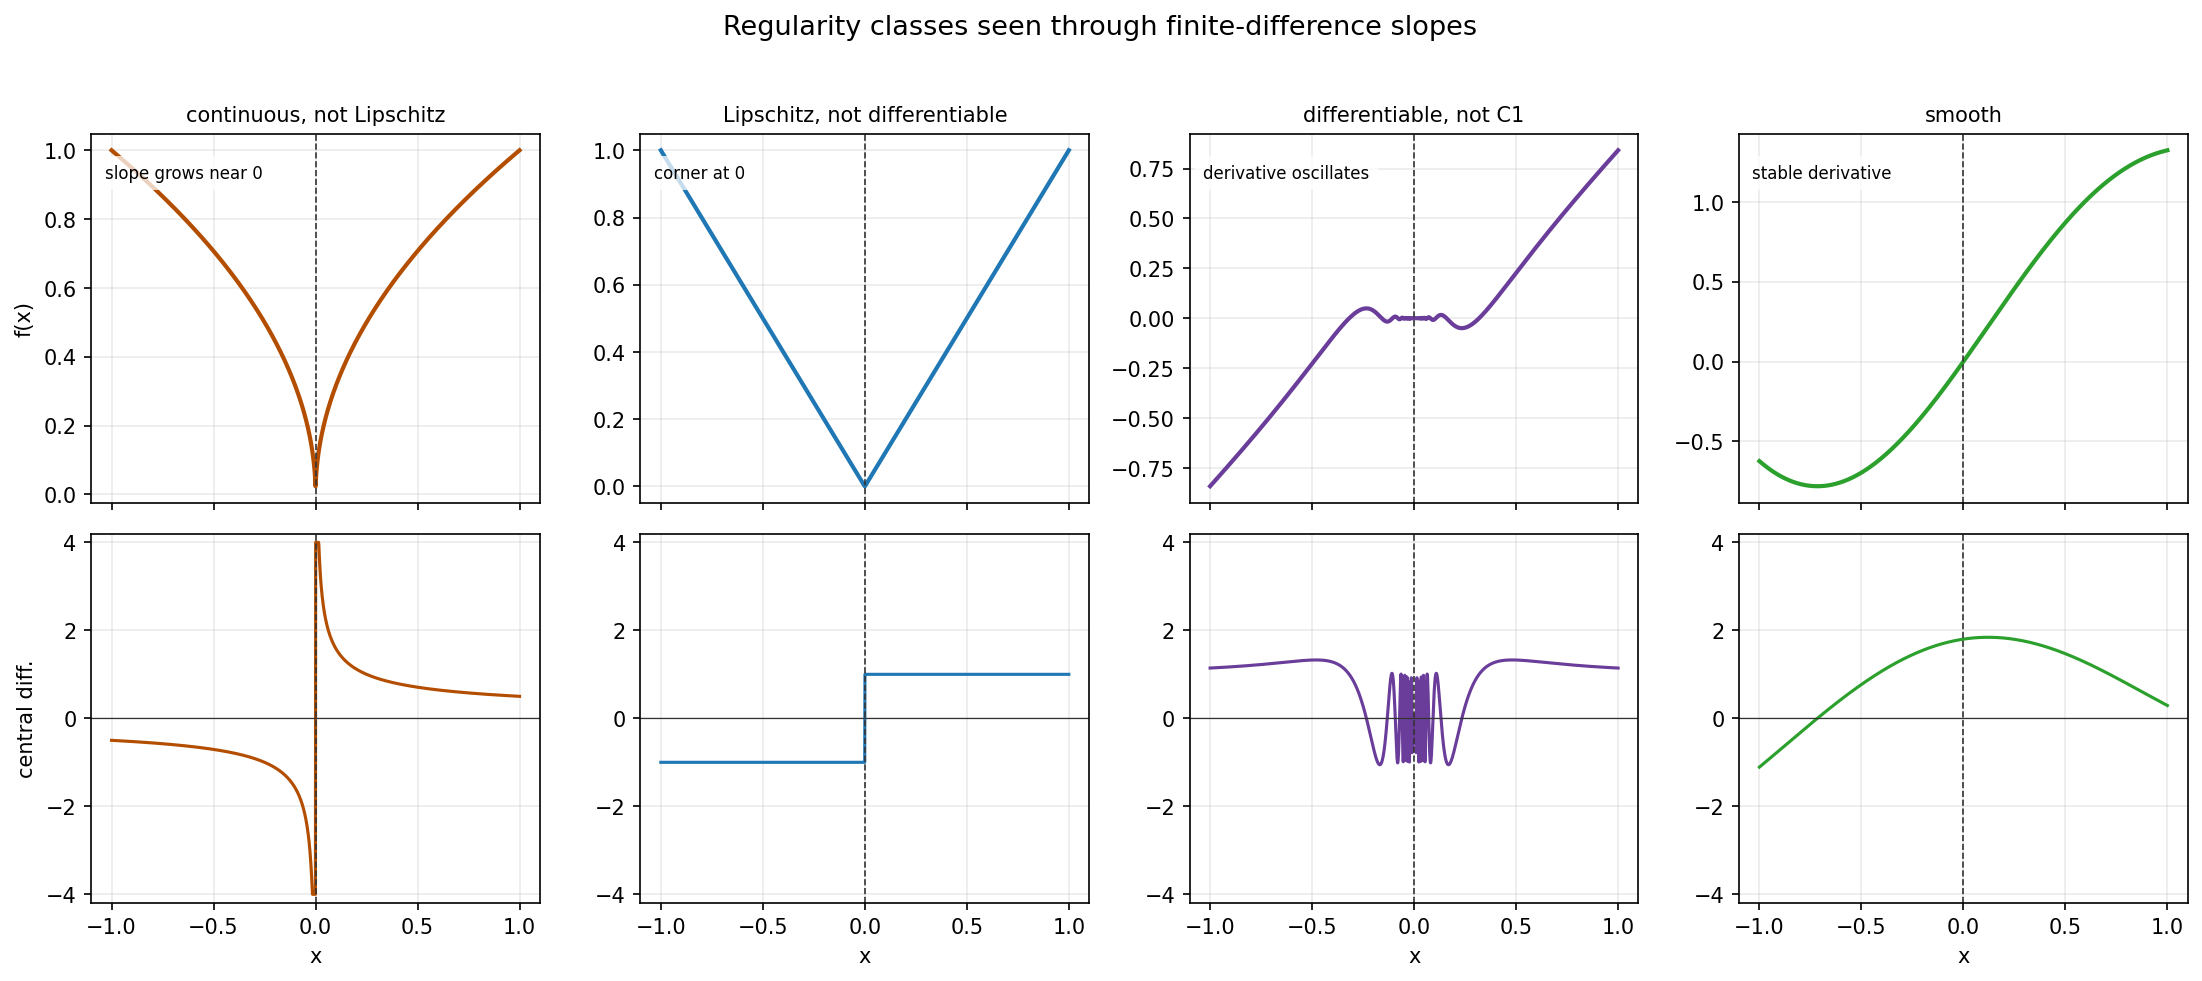

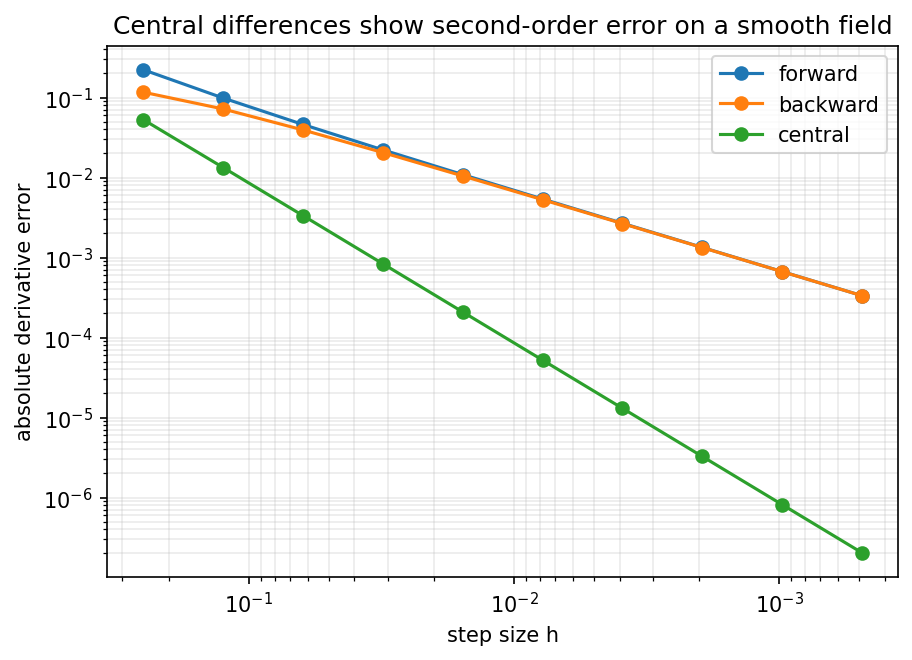

,h,forward_error,backward_error,central_error,forward_order,backward_order,central_order
6,0.003906,0.002686,0.002660,1.307736e-05,1.006999,0.992881,1.999990
7,0.001953,0.001340,0.001333,3.269347e-06,1.003514,0.996456,1.999997
8,0.000977,0.000669,0.000667,8.173371e-07,1.001761,0.998232,1.999999
9,0.000488,0.000334,0.000334,2.043342e-07,1.000881,0.999117,2.000000


In [2]:
def cusp(x):
    return np.abs(x)
def root_cusp(x):
    return np.sqrt(np.abs(x))
def differentiable_not_c1(x):
    out = np.zeros_like(x, dtype=float)
    mask = np.abs(x) > 1e-12
    out[mask] = x[mask] ** 2 * np.sin(1.0 / x[mask])
    return out
def smooth_example(x):
    return 0.35 * x**2 + np.sin(1.8 * x)
def central_difference(fn, x, h=1e-4):
    return (fn(x + h) - fn(x - h)) / (2 * h)

examples = [
    ("continuous, not Lipschitz", root_cusp, "slope grows near 0", "#b34d00"),
    ("Lipschitz, not differentiable", cusp, "corner at 0", "#1f77b4"),
    ("differentiable, not C1", differentiable_not_c1, "derivative oscillates", "#6a3d9a"),
    ("smooth", smooth_example, "stable derivative", "#2ca02c"),
]
x = np.linspace(-1.0, 1.0, 1800)
fig, axes = plt.subplots(2, 4, figsize=(14.8, 6.4), sharex=True)
for col, (title, fn, subtitle, color) in enumerate(examples):
    y = fn(x); dy = central_difference(fn, x)
    axes[0, col].plot(x, y, color=color, lw=2)
    axes[0, col].axvline(0, color="0.2", lw=0.8, ls="--")
    axes[0, col].set_title(title, fontsize=10); axes[0, col].grid(alpha=0.25)
    axes[0, col].set_ylabel("f(x)" if col == 0 else "")
    axes[0, col].text(0.03, 0.88, subtitle, transform=axes[0, col].transAxes, fontsize=8,
                      bbox={"facecolor":"white","edgecolor":"none","alpha":0.75})
    axes[1, col].plot(x, np.clip(dy, -4, 4), color=color, lw=1.5)
    axes[1, col].axhline(0, color="0.2", lw=0.6); axes[1, col].axvline(0, color="0.2", lw=0.8, ls="--")
    axes[1, col].set_ylim(-4.2, 4.2); axes[1, col].set_xlabel("x"); axes[1, col].grid(alpha=0.25)
    axes[1, col].set_ylabel("central diff." if col == 0 else "")
fig.suptitle("Regularity classes seen through finite-difference slopes", y=1.02, fontsize=13)
fig.tight_layout()
regularity_path = save_matplotlib(fig, CHAPTER_TOPIC, "lipschitz-smoothness-diagnostics.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(regularity_path)

def fd_function(t):
    return np.exp(0.2 * t) * np.sin(1.7 * t)
def fd_derivative(t):
    return np.exp(0.2 * t) * (0.2 * np.sin(1.7 * t) + 1.7 * np.cos(1.7 * t))

x0 = 0.4; true_derivative = float(fd_derivative(x0)); hs = np.array([2.0 ** (-k) for k in range(2, 12)])
rows = []
for h in hs:
    forward = (fd_function(x0 + h) - fd_function(x0)) / h
    backward = (fd_function(x0) - fd_function(x0 - h)) / h
    central = (fd_function(x0 + h) - fd_function(x0 - h)) / (2 * h)
    rows.append({"h":float(h), "forward_error":abs(float(forward)-true_derivative),
                 "backward_error":abs(float(backward)-true_derivative), "central_error":abs(float(central)-true_derivative)})
fd_table = pd.DataFrame(rows)
for column in ["forward_error", "backward_error", "central_error"]:
    order_column = column.replace("error", "order"); fd_table[order_column] = np.nan
    values = fd_table[column].to_numpy()
    for i in range(1, len(values)):
        fd_table.loc[i, order_column] = math.log(values[i - 1] / values[i], 2)
fd_table_path = save_table_csv(fd_table.to_dict("records"), CHAPTER_TOPIC, "finite-difference-error-orders.csv", root=BOOK_ROOT / "artifacts")
artifact_paths.append(fd_table_path)
fig, ax = plt.subplots(figsize=(6.8, 4.6))
for column, label in [("forward_error","forward"),("backward_error","backward"),("central_error","central")]:
    ax.loglog(fd_table["h"], fd_table[column], "o-", label=label)
ax.invert_xaxis(); ax.set_xlabel("step size h"); ax.set_ylabel("absolute derivative error")
ax.set_title("Central differences show second-order error on a smooth field")
ax.grid(True, which="both", alpha=0.25); ax.legend()
fd_plot_path = save_matplotlib(fig, CHAPTER_TOPIC, "finite-difference-error-orders.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(fd_plot_path)

checks["abs_empirical_lipschitz_max"] = float(np.max(np.abs(np.diff(cusp(x)) / np.diff(x))))
checks["root_cusp_slope_growth_1e_minus_6_vs_1e_minus_2"] = float((root_cusp(np.array([1e-6]))[0] / 1e-6) / (root_cusp(np.array([1e-2]))[0] / 1e-2))
checks["differentiable_not_c1_derivative_std_near_zero"] = float(np.std(central_difference(differentiable_not_c1, x[np.abs(x) < 0.08], h=1e-5)))
checks["central_difference_order_tail"] = float(np.nanmean(fd_table["central_order"].tail(4)))
checks["forward_difference_order_tail"] = float(np.nanmean(fd_table["forward_order"].tail(4)))
for path in [regularity_path, fd_plot_path, fd_table_path]:
    display_artifact(path, width=760)
fd_table.tail(4)


## 2. Scalar fields, vector fields, and signals

A scalar field stores one value at each point. A vector field stores a direction and magnitude at each point. In deep learning language, a signal over a domain stores feature channels at each point. The domain might be a plane in this toy example, but the same pattern appears on meshes, graphs, and manifolds: sample locations plus values living in a channel space.

The three panels below share one square domain. The left panel is a scalar field. The middle panel is a vector field with rotation and mild expansion. The right panel treats the domain as a three-channel signal, displayed as RGB after normalizing each channel. The inspection target is the separation between the geometry of the domain and the feature values attached to it.


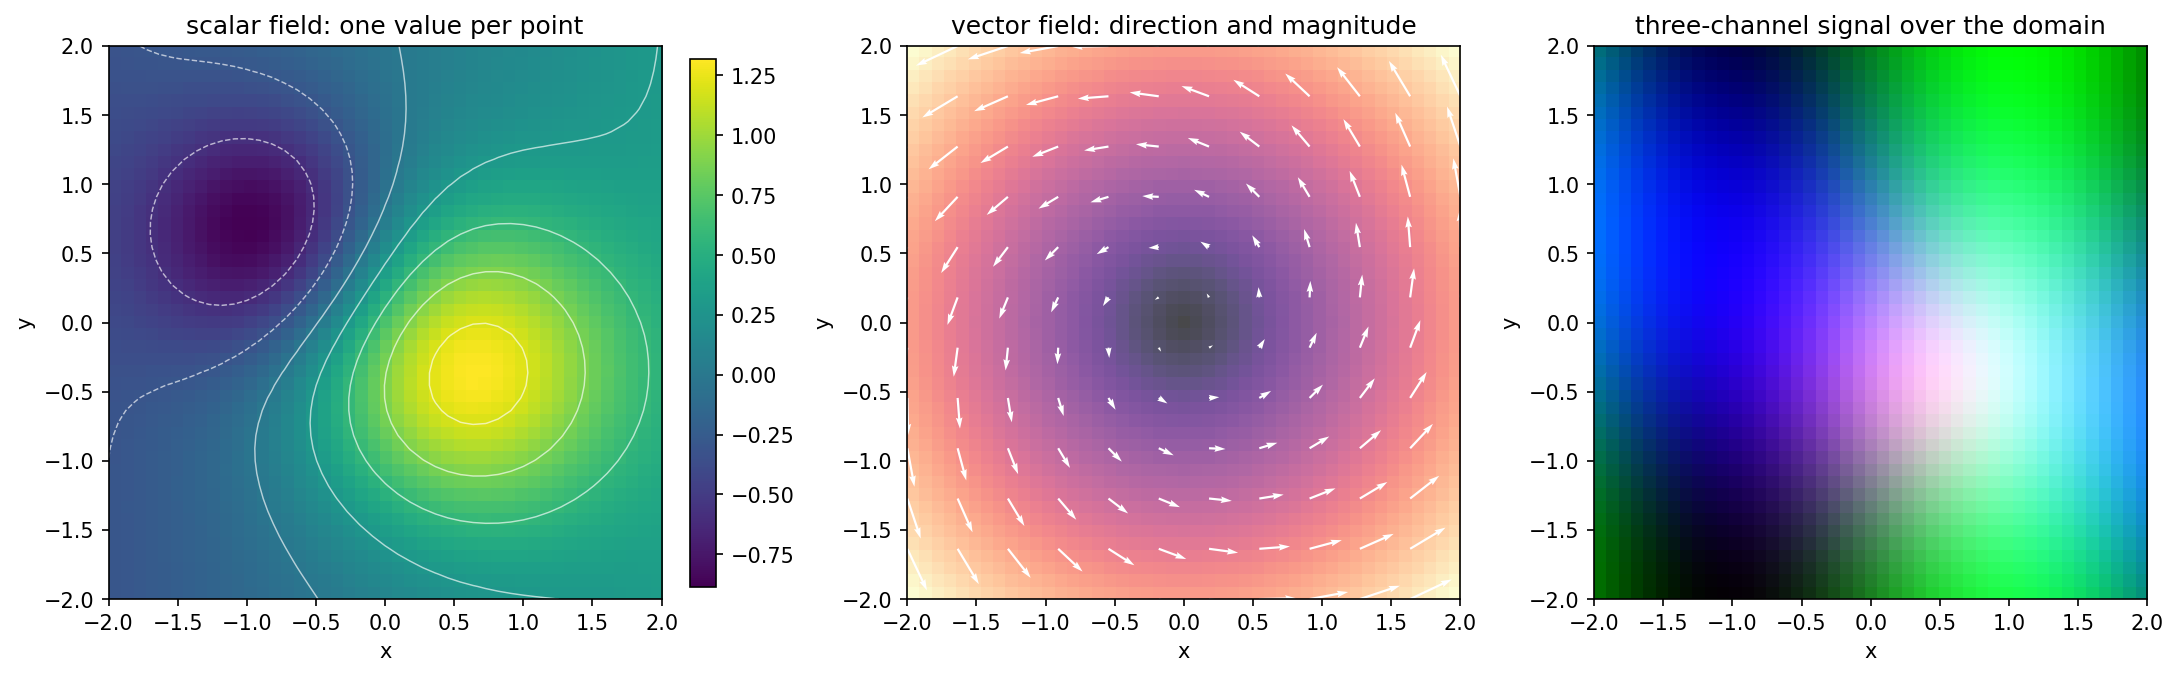

In [3]:
grid_n = 45
xs = np.linspace(-2.0, 2.0, grid_n); ys = np.linspace(-2.0, 2.0, grid_n)
X, Y = np.meshgrid(xs, ys)
scalar_field = 1.25*np.exp(-0.75*((X-0.55)**2+(Y+0.35)**2)) - 0.85*np.exp(-1.2*((X+0.85)**2+(Y-0.65)**2)) + 0.15*X
U = -Y + 0.25*X; V = X + 0.25*Y; speed = np.sqrt(U**2 + V**2)
channels = np.stack([
    np.exp(-0.8*((X-0.5)**2+(Y+0.4)**2)),
    0.5 + 0.5*np.sin(1.5*X),
    0.5 + 0.5*np.cos(1.2*Y + 0.4*X),
], axis=-1)
channels_rgb = (channels - channels.min(axis=(0,1))) / (np.ptp(channels, axis=(0,1)) + 1e-12)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)
im0 = axes[0].imshow(scalar_field, extent=[xs.min(), xs.max(), ys.min(), ys.max()], origin="lower", cmap="viridis")
axes[0].contour(X, Y, scalar_field, colors="white", linewidths=0.7, alpha=0.65)
axes[0].set_title("scalar field: one value per point"); fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
skip = (slice(None,None,4), slice(None,None,4))
axes[1].imshow(speed, extent=[xs.min(), xs.max(), ys.min(), ys.max()], origin="lower", cmap="magma", alpha=0.72)
axes[1].quiver(X[skip], Y[skip], U[skip], V[skip], color="white", scale=32, width=0.004)
axes[1].set_title("vector field: direction and magnitude")
axes[2].imshow(channels_rgb, extent=[xs.min(), xs.max(), ys.min(), ys.max()], origin="lower")
axes[2].set_title("three-channel signal over the domain")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
fields_path = save_matplotlib(fig, CHAPTER_TOPIC, "scalar-vector-signal-fields.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(fields_path)
checks["scalar_field_min"] = float(scalar_field.min()); checks["scalar_field_max"] = float(scalar_field.max())
checks["vector_field_speed_max"] = float(speed.max()); checks["signal_channel_count"] = int(channels.shape[-1])
display_artifact(fields_path, width=900)


## 3. Gradients and Jacobians as local linear data

For a scalar field, the gradient is the vector whose dot product with a direction gives the directional derivative. That is why gradient arrows cut across level sets: moving along a level set should not change the scalar value to first order.

For a vector-valued map, the Jacobian is the corresponding local linear map. A small circle around a point usually becomes an ellipse after applying the Jacobian. The nonlinear map may curve the image of the circle, but the mismatch should shrink quadratically with the radius when the map is smooth.


Symbolic Jacobian:


Matrix([
[       1, 7*cos(y)/20],
[cos(x)/4,           1]])

directional derivative error = 1.459e-12
local linearization order estimate = 2.04


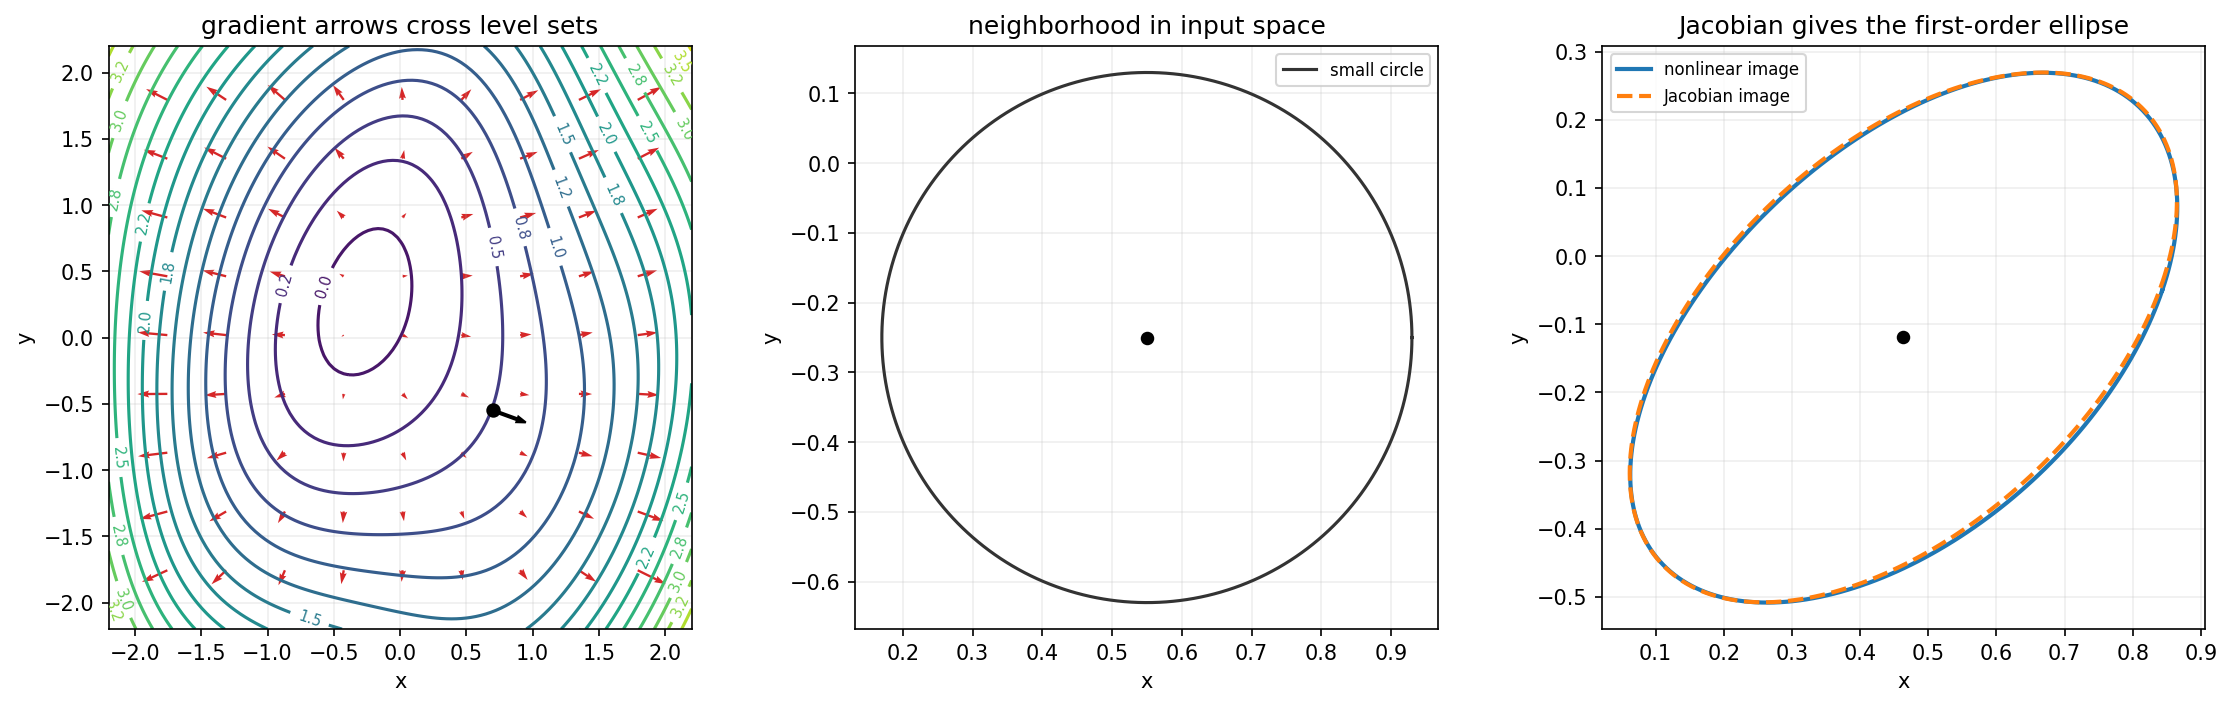

In [4]:
def scalar_potential(x, y):
    return 0.5*x**2 + 0.25*y**2 + 0.2*np.sin(2*x - y)
def grad_potential(x, y):
    return x + 0.4*np.cos(2*x-y), 0.5*y - 0.2*np.cos(2*x-y)
def nonlinear_map(points):
    px = points[:,0]; py = points[:,1]
    return np.column_stack([px + 0.35*np.sin(py), py + 0.25*np.sin(px)])
def jacobian_map(point):
    px, py = point
    return np.array([[1.0, 0.35*np.cos(py)], [0.25*np.cos(px), 1.0]])

xg = np.linspace(-2.2, 2.2, 120); yg = np.linspace(-2.2, 2.2, 120)
GX, GY = np.meshgrid(xg, yg); GZ = scalar_potential(GX, GY); GGX, GGY = grad_potential(GX, GY)
p0 = np.array([0.7, -0.55]); gp = np.array(grad_potential(p0[0], p0[1]), dtype=float)
direction = np.array([0.6, 0.8]); h = 1e-5
directional_fd = (scalar_potential(*(p0+h*direction)) - scalar_potential(*(p0-h*direction))) / (2*h)
directional_dot = float(np.dot(gp, direction))
base = np.array([0.55, -0.25]); J = jacobian_map(base); theta = np.linspace(0, 2*np.pi, 240); r = 0.38
circle = base + r*np.column_stack([np.cos(theta), np.sin(theta)])
warped = nonlinear_map(circle); linearized = nonlinear_map(base.reshape(1,2))[0] + (J @ (circle-base).T).T
radii = np.array([0.4, 0.2, 0.1, 0.05]); lin_errors = []
for radius in radii:
    local_circle = base + radius*np.column_stack([np.cos(theta), np.sin(theta)])
    actual = nonlinear_map(local_circle); approx = nonlinear_map(base.reshape(1,2))[0] + (J @ (local_circle-base).T).T
    lin_errors.append(float(np.max(np.linalg.norm(actual-approx, axis=1))))
local_order = math.log(lin_errors[-2] / lin_errors[-1], radii[-2] / radii[-1])
sx, sy = sp.symbols("x y")
J_sym = sp.Matrix([sx + sp.Rational(35,100)*sp.sin(sy), sy + sp.Rational(25,100)*sp.sin(sx)]).jacobian([sx, sy])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
levels = axes[0].contour(GX, GY, GZ, levels=18, cmap="viridis"); axes[0].clabel(levels, inline=True, fontsize=7, fmt="%.1f")
qskip = (slice(None,None,12), slice(None,None,12))
axes[0].quiver(GX[qskip], GY[qskip], GGX[qskip], GGY[qskip], color="#d62728", scale=42, width=0.004)
axes[0].scatter([p0[0]], [p0[1]], color="black", s=35, zorder=3)
axes[0].arrow(p0[0], p0[1], 0.45*gp[0], 0.45*gp[1], color="black", width=0.015, length_includes_head=True)
axes[0].set_title("gradient arrows cross level sets")
axes[1].plot(circle[:,0], circle[:,1], color="0.2", label="small circle"); axes[1].scatter([base[0]], [base[1]], color="black", s=30)
axes[1].set_title("neighborhood in input space"); axes[1].legend(fontsize=8)
axes[2].plot(warped[:,0], warped[:,1], color="#1f77b4", lw=2, label="nonlinear image")
axes[2].plot(linearized[:,0], linearized[:,1], color="#ff7f0e", lw=2, ls="--", label="Jacobian image")
axes[2].scatter(*nonlinear_map(base.reshape(1,2))[0], color="black", s=30)
axes[2].set_title("Jacobian gives the first-order ellipse"); axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal"); ax.grid(alpha=0.2)
local_path = save_matplotlib(fig, CHAPTER_TOPIC, "gradient-jacobian-local-linearization.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(local_path)
checks["gradient_directional_error"] = float(abs(directional_fd - directional_dot))
checks["jacobian_local_order"] = float(local_order); checks["jacobian_symbolic_trace"] = str(sp.trace(J_sym))
print("Symbolic Jacobian:"); display(J_sym)
print(f"directional derivative error = {checks['gradient_directional_error']:.3e}")
print(f"local linearization order estimate = {local_order:.2f}")
display_artifact(local_path, width=920)


## 4. Integrals, divergence, flux, and the Laplacian

Derivatives measure local variation. Integrals accumulate local contributions. The divergence theorem is the bridge that lets a volume source-sink total be checked on the boundary. This matters in geometric learning because many useful operators are local, but their design constraints are global: conservation, smoothness, and invariance.

The next artifact ties four computations together. The Riemann panel shows accumulation by rectangles. The heatmap panel uses iterated numerical integration as a Fubini-style check. The flux panel compares total divergence inside a square to flow through the boundary. The Laplacian panel shows a heat-step update, where local second differences move the field toward smoother neighboring values.


boundary flux - volume divergence = 2.220e-16
rotation residual for the Laplacian = 0


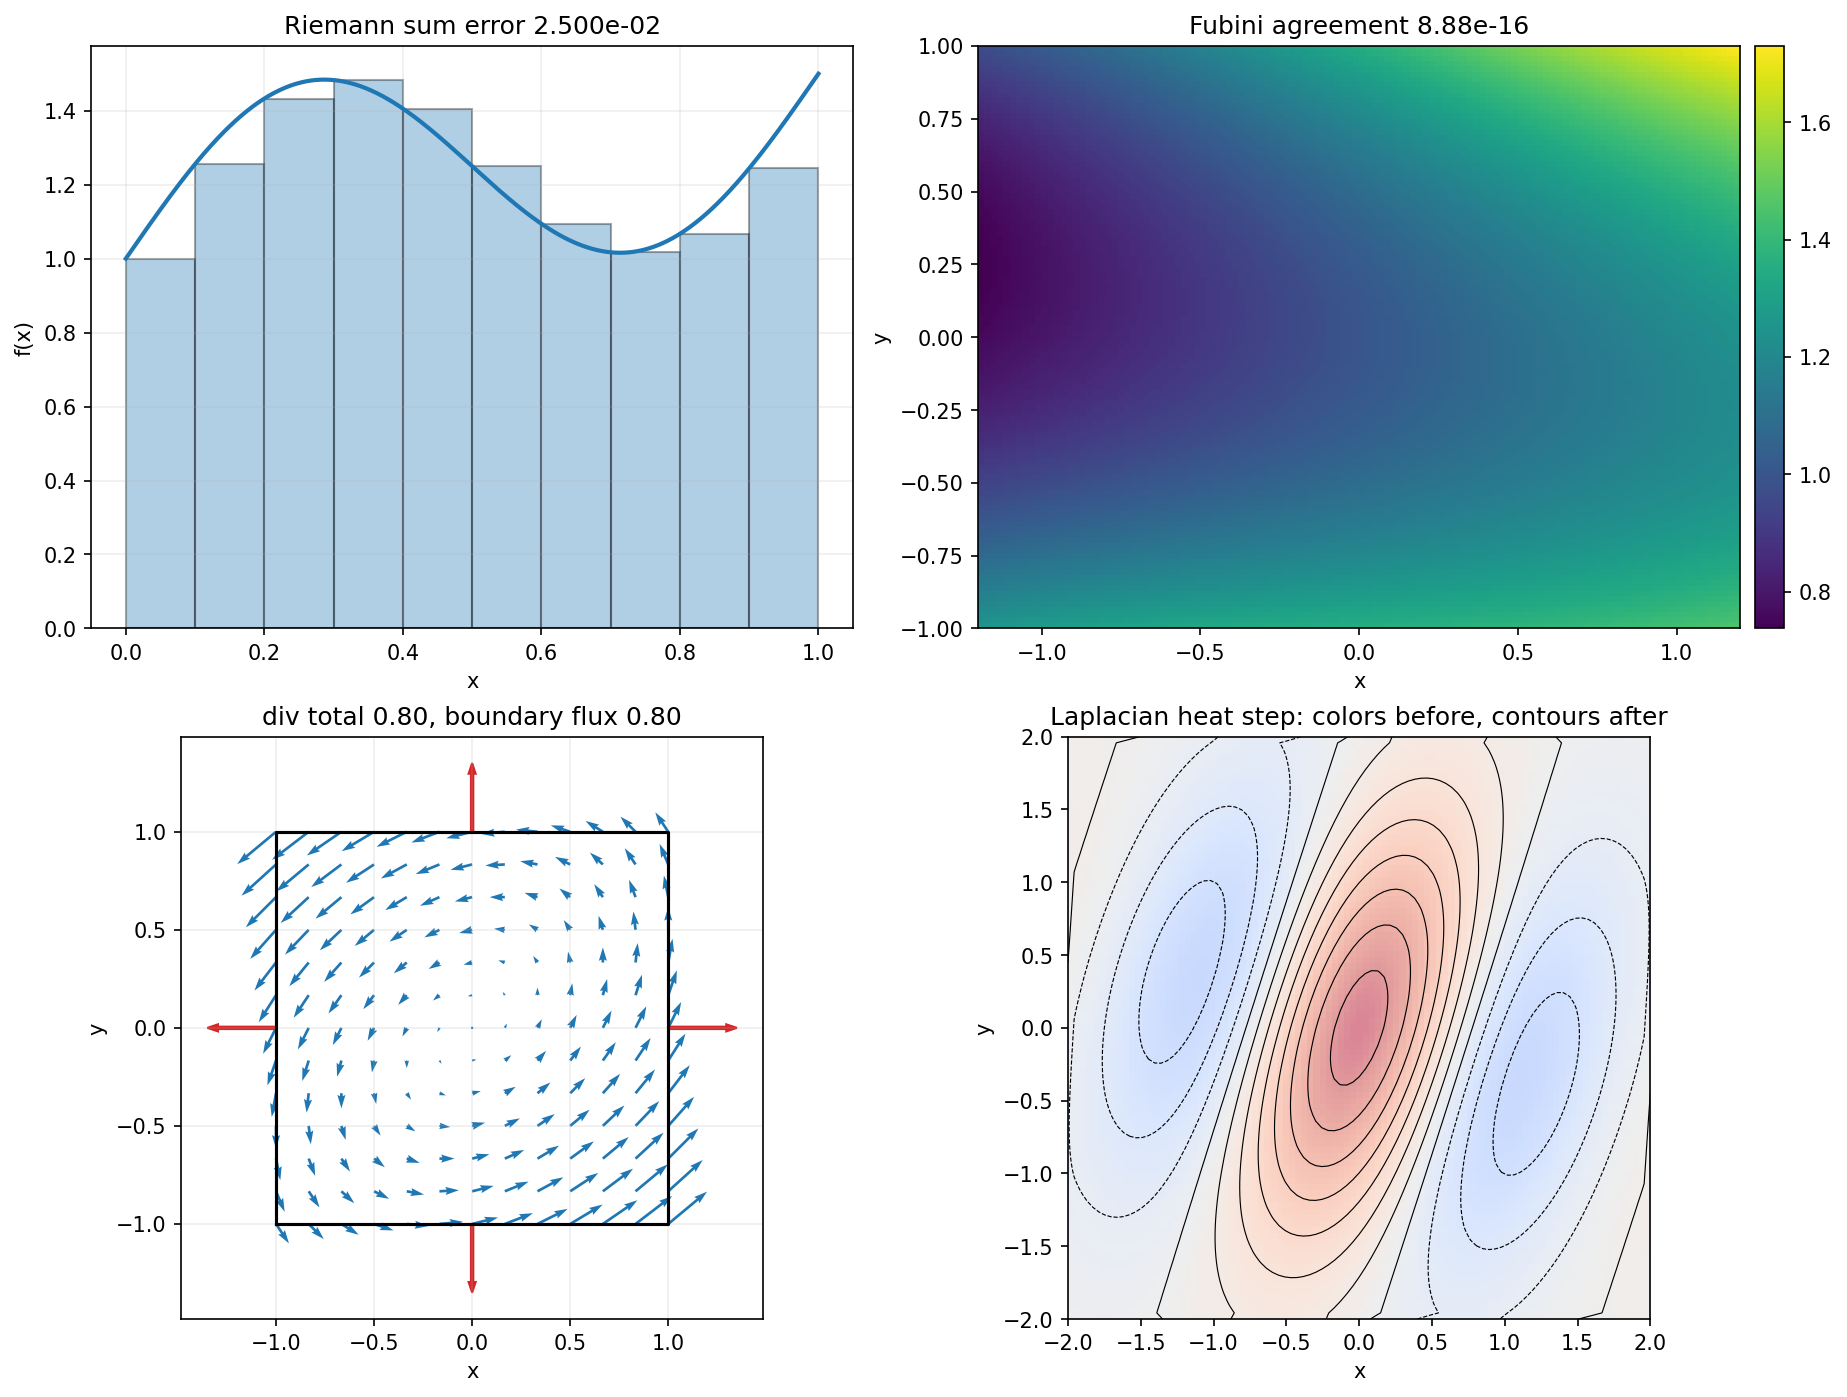

In [5]:
def one_dim_integrand(t):
    return 1.0 + 0.35*np.sin(2*np.pi*t) + 0.5*t

t = np.linspace(0, 1, 500); n_rect = 10; edges = np.linspace(0, 1, n_rect+1); left = edges[:-1]; width = edges[1]-edges[0]
riemann_sum = float(np.sum(one_dim_integrand(left)*width))
quad_value = float(integrate.quad(lambda z: float(one_dim_integrand(z)), 0, 1)[0])

fx = np.linspace(-1.2, 1.2, 120); fy = np.linspace(-1.0, 1.0, 110); FX, FY = np.meshgrid(fx, fy)
fubini_field = 1.0 + 0.2*FX + 0.35*FY**2 + 0.15*np.sin(FX*FY)
iter_yx = float(np.trapezoid(np.trapezoid(fubini_field, fy, axis=0), fx))
iter_xy = float(np.trapezoid(np.trapezoid(fubini_field, fx, axis=1), fy))

def vector_flux_field(x, y):
    return 0.4*x - 0.8*y, -0.2*y + 0.8*x
def integrate_edge(points, normals):
    vx, vy = vector_flux_field(points[:,0], points[:,1]); density = vx*normals[:,0] + vy*normals[:,1]
    return float(np.trapezoid(density, np.linspace(-1, 1, len(points))))
edge_s = np.linspace(-1, 1, 500)
top = np.column_stack([edge_s, np.ones_like(edge_s)]); bottom = np.column_stack([edge_s, -np.ones_like(edge_s)])
right = np.column_stack([np.ones_like(edge_s), edge_s]); left_edge = np.column_stack([-np.ones_like(edge_s), edge_s])
flux_total = integrate_edge(top, np.tile([0.0,1.0], (len(edge_s),1))) + integrate_edge(bottom, np.tile([0.0,-1.0], (len(edge_s),1))) + integrate_edge(right, np.tile([1.0,0.0], (len(edge_s),1))) + integrate_edge(left_edge, np.tile([-1.0,0.0], (len(edge_s),1)))
volume_divergence = (0.4 - 0.2) * 4.0

lap_x = np.linspace(-2, 2, 95); lap_y = np.linspace(-2, 2, 95); LX, LY = np.meshgrid(lap_x, lap_y)
field_u = np.exp(-0.45*(LX**2 + LY**2)) * np.cos(2.2*LX - 0.7*LY)
dx = lap_x[1]-lap_x[0]; dy = lap_y[1]-lap_y[0]
lap_u = np.zeros_like(field_u)
lap_u[1:-1,1:-1] = (field_u[1:-1,2:] - 2*field_u[1:-1,1:-1] + field_u[1:-1,:-2]) / dx**2 + (field_u[2:,1:-1] - 2*field_u[1:-1,1:-1] + field_u[:-2,1:-1]) / dy**2
heat_step = field_u + 0.035*lap_u
uy, ux = np.gradient(field_u, dy, dx)
dirichlet_energy = float(np.trapezoid(np.trapezoid(ux**2 + uy**2, lap_x, axis=1), lap_y))

u, v = sp.symbols("u v"); x_sym, y_sym = sp.symbols("x y"); angle = sp.pi/5
rot = sp.Matrix([[sp.cos(angle), -sp.sin(angle)], [sp.sin(angle), sp.cos(angle)]]) * sp.Matrix([u, v])
f_sym = x_sym**2 + x_sym*y_sym + 3*y_sym**2 + sp.sin(x_sym-y_sym)
lap_xy = sp.diff(f_sym, x_sym, 2) + sp.diff(f_sym, y_sym, 2)
f_rot = f_sym.subs({x_sym: rot[0], y_sym: rot[1]})
lap_uv = sp.diff(f_rot, u, 2) + sp.diff(f_rot, v, 2)
lap_at_rot = lap_xy.subs({x_sym: rot[0], y_sym: rot[1]})
lap_rotation_residual = sp.simplify(lap_uv - lap_at_rot)

fig, axes = plt.subplots(2, 2, figsize=(12.2, 9.2), constrained_layout=True)
axes[0,0].plot(t, one_dim_integrand(t), color="#1f77b4", lw=2)
axes[0,0].bar(left, one_dim_integrand(left), width=width, align="edge", alpha=0.35, edgecolor="black", color="#1f77b4")
axes[0,0].set_title(f"Riemann sum error {abs(riemann_sum-quad_value):.3e}"); axes[0,0].set_xlabel("x"); axes[0,0].set_ylabel("f(x)"); axes[0,0].grid(alpha=0.2)
im = axes[0,1].imshow(fubini_field, extent=[fx.min(), fx.max(), fy.min(), fy.max()], origin="lower", cmap="viridis", aspect="auto")
axes[0,1].set_title(f"Fubini agreement {abs(iter_xy-iter_yx):.2e}"); axes[0,1].set_xlabel("x"); axes[0,1].set_ylabel("y"); fig.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.02)
qx = np.linspace(-1,1,13); qy = np.linspace(-1,1,13); QX, QY = np.meshgrid(qx, qy); QU, QV = vector_flux_field(QX, QY)
axes[1,0].quiver(QX, QY, QU, QV, color="#1f77b4", scale=18); axes[1,0].plot([-1,1,1,-1,-1], [-1,-1,1,1,-1], color="black", lw=1.5)
for px, py, nx, ny in [(0,1,0,0.35),(0,-1,0,-0.35),(1,0,0.35,0),(-1,0,-0.35,0)]:
    axes[1,0].arrow(px, py, nx, ny, width=0.012, color="#d62728", length_includes_head=True)
axes[1,0].set_title(f"div total {volume_divergence:.2f}, boundary flux {flux_total:.2f}"); axes[1,0].set_aspect("equal"); axes[1,0].set_xlabel("x"); axes[1,0].set_ylabel("y"); axes[1,0].grid(alpha=0.2)
vmax = np.max(np.abs(np.r_[field_u.ravel(), heat_step.ravel()]))
axes[1,1].imshow(field_u, extent=[lap_x.min(), lap_x.max(), lap_y.min(), lap_y.max()], origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax, alpha=0.48)
axes[1,1].contour(LX, LY, heat_step, levels=12, colors="black", linewidths=0.55)
axes[1,1].set_title("Laplacian heat step: colors before, contours after"); axes[1,1].set_xlabel("x"); axes[1,1].set_ylabel("y")
integral_path = save_matplotlib(fig, CHAPTER_TOPIC, "integrals-divergence-laplacian.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(integral_path)
checks["riemann_sum_error_n10"] = float(abs(riemann_sum-quad_value)); checks["fubini_iterated_integral_difference"] = float(abs(iter_xy-iter_yx))
checks["divergence_flux_error_square"] = float(abs(flux_total-volume_divergence)); checks["dirichlet_energy_nonnegative"] = bool(dirichlet_energy >= 0)
checks["dirichlet_energy_value"] = dirichlet_energy; checks["laplacian_rotation_residual"] = str(lap_rotation_residual)
print(f"boundary flux - volume divergence = {flux_total-volume_divergence:.3e}")
print(f"rotation residual for the Laplacian = {lap_rotation_residual}")
display_artifact(integral_path, width=880)


## 5. Loss landscapes and gradient descent

A loss function is a scalar field on parameter space. Real neural networks are too high-dimensional to see directly, but a two-parameter toy loss is enough to inspect the calculus. Gradient descent moves opposite the gradient, so the update path should run downhill when the step size is controlled. The static contour plot gives a reproducible snapshot, and the Plotly artifact lets you rotate the same surface.


loss dropped from 1.753 to 0.816 in 85 steps


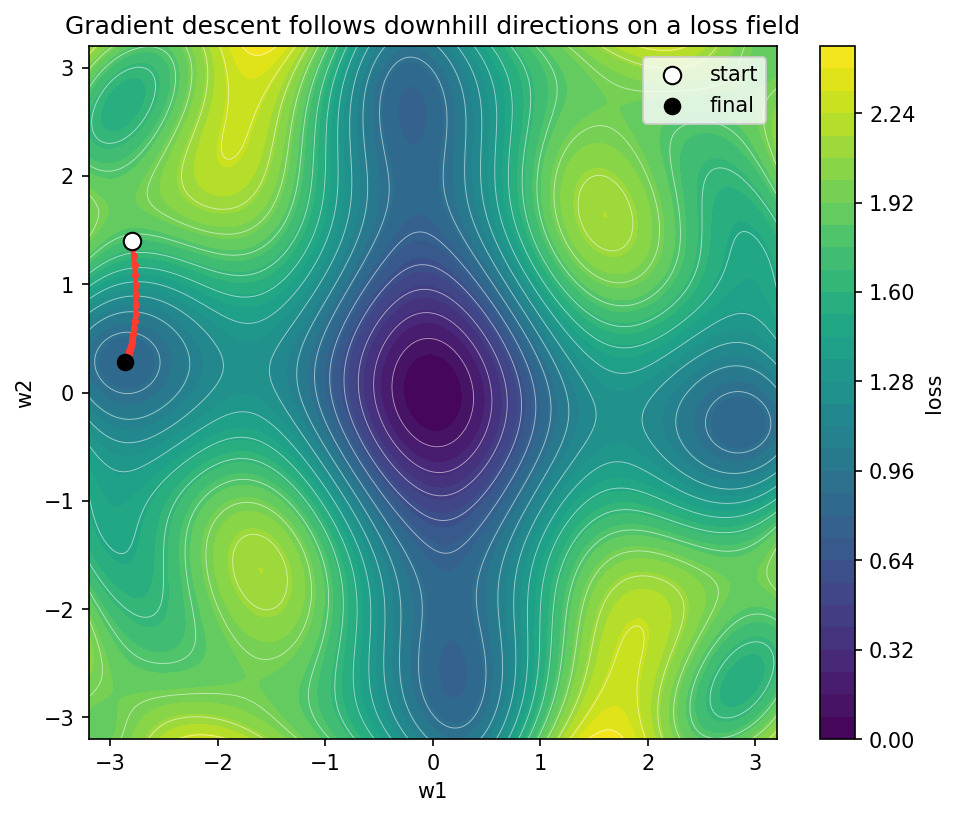

In [6]:
def loss_value(w):
    w1, w2 = w
    return float(0.1*(w1**2+w2**2) + np.sin(w1)**2 + 0.55*np.sin(w2)**2 + 0.18*np.sin(w1*w2))
def loss_grid(W1, W2):
    return 0.1*(W1**2+W2**2) + np.sin(W1)**2 + 0.55*np.sin(W2)**2 + 0.18*np.sin(W1*W2)
def loss_grad(w):
    w1, w2 = w
    return np.array([0.2*w1 + 2*np.sin(w1)*np.cos(w1) + 0.18*w2*np.cos(w1*w2),
                     0.2*w2 + 1.1*np.sin(w2)*np.cos(w2) + 0.18*w1*np.cos(w1*w2)], dtype=float)

w = np.array([-2.8, 1.4], dtype=float); path = [w.copy()]; losses = [loss_value(w)]; eta = 0.08
for _ in range(85):
    grad = loss_grad(w); trial_eta = eta; current = loss_value(w)
    while True:
        candidate = w - trial_eta*grad; candidate_loss = loss_value(candidate)
        if candidate_loss <= current or trial_eta < 1e-5:
            break
        trial_eta *= 0.5
    w = candidate; path.append(w.copy()); losses.append(candidate_loss)
path = np.array(path); losses = np.array(losses)
w1_axis = np.linspace(-3.2, 3.2, 180); w2_axis = np.linspace(-3.2, 3.2, 180)
W1, W2 = np.meshgrid(w1_axis, w2_axis); L = loss_grid(W1, W2); path_z = np.array([loss_value(point) for point in path])
fig, ax = plt.subplots(figsize=(7.4, 6.0))
contours = ax.contourf(W1, W2, L, levels=34, cmap="viridis"); ax.contour(W1, W2, L, levels=18, colors="white", linewidths=0.45, alpha=0.55)
ax.plot(path[:,0], path[:,1], color="#ff3b30", lw=2.3, marker="o", ms=2.5)
ax.scatter(path[0,0], path[0,1], color="white", edgecolor="black", s=70, label="start", zorder=3)
ax.scatter(path[-1,0], path[-1,1], color="black", s=55, label="final", zorder=3)
ax.set_title("Gradient descent follows downhill directions on a loss field"); ax.set_xlabel("w1"); ax.set_ylabel("w2"); ax.legend(loc="upper right")
fig.colorbar(contours, ax=ax, label="loss")
loss_png_path = save_matplotlib(fig, CHAPTER_TOPIC, "loss-landscape-gradient-flow.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(loss_png_path)
surface = go.Figure(data=[
    go.Surface(x=w1_axis, y=w2_axis, z=L, colorscale="Viridis", opacity=0.86, name="loss"),
    go.Scatter3d(x=path[:,0], y=path[:,1], z=path_z+0.03, mode="lines+markers", line={"color":"red","width":6}, marker={"size":3,"color":"red"}, name="descent path"),
])
surface.update_layout(title="Interactive loss landscape with a gradient descent path", scene={"xaxis_title":"w1", "yaxis_title":"w2", "zaxis_title":"L(w)", "camera":{"eye":{"x":1.45,"y":-1.65,"z":1.1}}}, margin={"l":0,"r":0,"t":45,"b":0})
loss_html_path = save_plotly_html(surface, CHAPTER_TOPIC, "loss-landscape-gradient-flow.html", root=BOOK_ROOT / "artifacts")
artifact_paths.append(loss_html_path)
checks["loss_initial"] = float(losses[0]); checks["loss_final"] = float(losses[-1]); checks["loss_drop"] = float(losses[0]-losses[-1])
checks["loss_monotone_steps"] = int(np.sum(np.diff(losses) <= 1e-12))
print(f"loss dropped from {losses[0]:.3f} to {losses[-1]:.3f} in {len(losses)-1} steps")
display_artifact(loss_png_path, width=760); display_artifact(loss_html_path, width="100%", height=560)


## 6. Backpropagation as a chain-rule graph

Backpropagation is vector calculus applied to a composed computation. The graph below is deliberately tiny: a scalar input passes through an affine map, a `tanh` activation, another affine map, and a squared-error loss. The point is not neural-network capacity. The point is to verify that multiplying local derivatives along the graph gives the same parameter gradients as automatic differentiation.


manual gradients: {'w2': 0.08348565105294148, 'b2': 0.1236696439356012, 'w1': -0.10837070344484043, 'b1': -0.07740764531774316}
autograd gradients: {'w1': -0.10837070344484029, 'b1': -0.07740764531774307, 'w2': 0.08348565105294142, 'b2': 0.12366964393560109}
max absolute difference = 1.388e-16


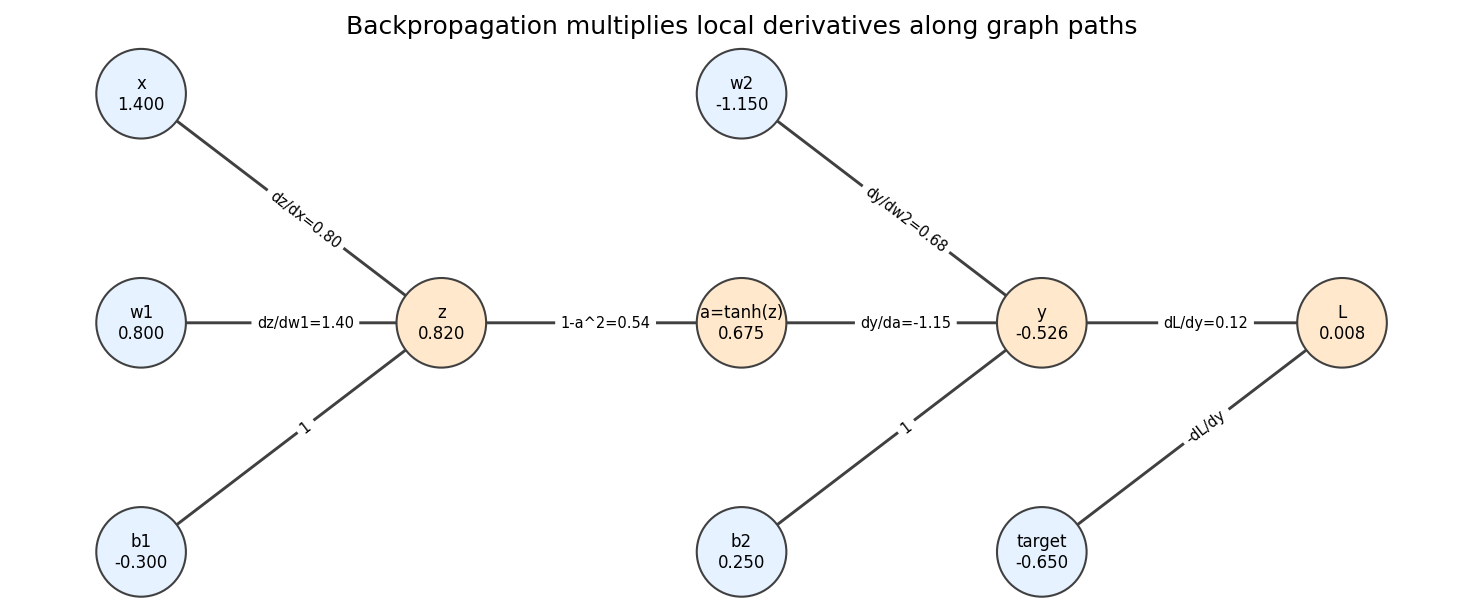

In [7]:
import networkx as nx
x_val = 1.4; y_target = -0.65; w1, b1, w2, b2 = 0.8, -0.3, -1.15, 0.25
z = w1*x_val + b1; a = math.tanh(z); y_pred = w2*a + b2; loss = 0.5*(y_pred-y_target)**2
dL_dy = y_pred-y_target; dy_da = w2; da_dz = 1-a**2
manual_grads = {"w2": dL_dy*a, "b2": dL_dy, "w1": dL_dy*dy_da*da_dz*x_val, "b1": dL_dy*dy_da*da_dz}
torch_params = {name: torch.tensor(value, dtype=torch.float64, requires_grad=True) for name, value in {"w1":w1,"b1":b1,"w2":w2,"b2":b2}.items()}
tx = torch.tensor(x_val, dtype=torch.float64); ty = torch.tensor(y_target, dtype=torch.float64)
tz = torch_params["w1"]*tx + torch_params["b1"]; ta = torch.tanh(tz); ty_pred = torch_params["w2"]*ta + torch_params["b2"]
tl = 0.5*(ty_pred-ty)**2; tl.backward()
autograd_grads = {name: float(param.grad) for name, param in torch_params.items()}
max_abs_grad_diff = max(abs(manual_grads[name]-autograd_grads[name]) for name in manual_grads)
G = nx.DiGraph(); node_values = {"x":x_val,"w1":w1,"b1":b1,"z":z,"a=tanh(z)":a,"w2":w2,"b2":b2,"y":y_pred,"target":y_target,"L":loss}
for node, value in node_values.items(): G.add_node(node, value=value)
edges = [("x","z",f"dz/dx={w1:.2f}"),("w1","z",f"dz/dw1={x_val:.2f}"),("b1","z","1"),("z","a=tanh(z)",f"1-a^2={da_dz:.2f}"),("a=tanh(z)","y",f"dy/da={w2:.2f}"),("w2","y",f"dy/dw2={a:.2f}"),("b2","y","1"),("y","L",f"dL/dy={dL_dy:.2f}"),("target","L","-dL/dy")]
for source, target, label in edges: G.add_edge(source, target, label=label)
pos = {"x":(0,2),"w1":(0,1),"b1":(0,0),"z":(1.5,1),"a=tanh(z)":(3,1),"w2":(3,2),"b2":(3,0),"y":(4.5,1),"target":(4.5,0),"L":(6,1)}
fig, ax = plt.subplots(figsize=(12.5, 4.8))
node_labels = {node:f"{node}\n{value:.3f}" for node, value in node_values.items()}
colors = ["#e6f2ff" if node not in {"L","z","a=tanh(z)","y"} else "#ffe8cc" for node in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1850, edgecolors="0.25", linewidths=1.0, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.4, edge_color="0.25", ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), font_size=7, ax=ax, label_pos=0.55)
ax.set_title("Backpropagation multiplies local derivatives along graph paths"); ax.axis("off")
backprop_path = save_matplotlib(fig, CHAPTER_TOPIC, "backprop-chain-rule-gradient-check.png", root=BOOK_ROOT / "artifacts")
plt.close(fig); artifact_paths.append(backprop_path)
checks["backprop_max_abs_grad_diff"] = float(max_abs_grad_diff); checks["backprop_graph_is_dag"] = bool(nx.is_directed_acyclic_graph(G))
print("manual gradients:", manual_grads); print("autograd gradients:", autograd_grads); print(f"max absolute difference = {max_abs_grad_diff:.3e}")
display_artifact(backprop_path, width=920)


## Applied lab: step size as a geometric choice

The learning rate is a scalar, but it has geometric meaning: it chooses how far to move in parameter space along the negative gradient. Too small is slow; too large can skip across valleys or require repeated backtracking. This lab reruns the same loss from the same initial point with several fixed step sizes and records the final loss.


In [8]:
def run_fixed_step_descent(eta_value, steps=70):
    w = np.array([-2.8, 1.4], dtype=float); values = [loss_value(w)]; stable = True
    for _ in range(steps):
        w = w - eta_value * loss_grad(w); value = loss_value(w); values.append(value)
        if not np.isfinite(value) or value > 20:
            stable = False; break
    values_arr = np.array(values, dtype=float)
    return {"learning_rate":eta_value, "steps_run":int(len(values_arr)-1), "initial_loss":float(values_arr[0]),
            "final_loss":float(values_arr[-1]), "best_loss":float(np.nanmin(values_arr)),
            "monotone_fraction":float(np.mean(np.diff(values_arr) <= 1e-12)) if len(values_arr) > 1 else 1.0,
            "stable":bool(stable)}
lab_rows = [run_fixed_step_descent(eta) for eta in [0.02, 0.06, 0.12, 0.24, 0.42]]
lab_table = pd.DataFrame(lab_rows)
lab_table_path = save_table_csv(lab_table.to_dict("records"), CHAPTER_TOPIC, "gradient-descent-step-size-lab.csv", root=BOOK_ROOT / "artifacts")
artifact_paths.append(lab_table_path)
checks["lab_best_fixed_step_loss"] = float(lab_table["best_loss"].min())
checks["lab_unstable_step_count"] = int((~lab_table["stable"]).sum())
display(lab_table); display_artifact(lab_table_path)


,learning_rate,steps_run,initial_loss,final_loss,best_loss,monotone_fraction,stable
0,0.02,70,1.752715,0.823720,0.823720,1.0,True
1,0.06,70,1.752715,0.815775,0.815775,1.0,True
2,0.12,70,1.752715,0.815775,0.815775,1.0,True
3,0.24,70,1.752715,0.815775,0.815775,1.0,True
4,0.42,70,1.752715,0.815775,0.815775,1.0,True


## Sanity checks

The final cell verifies the main computational claims: finite differences have the expected order on a smooth function, the gradient predicts directional change, the Jacobian approximation behaves like a first-order model, volume divergence equals boundary flux for the square test, the Laplacian is rotation-invariant under an orthogonal coordinate change, gradient descent lowers the loss, and hand backpropagation matches autograd.

## Takeaways

Vector calculus supplies the local-to-global grammar used throughout geometric deep learning. Gradients and Jacobians are local linear data. Integrals and divergence connect local rates to accumulated quantities. Laplacians measure local variation and support smoothness priors on Euclidean and non-Euclidean domains. Backpropagation is the chain rule organized over a computation graph.


In [9]:
checks["artifact_count"] = int(len(artifact_paths) + 1)
checks_path = save_json(checks, CHAPTER_TOPIC, "vector-calculus-invariants.json", root=BOOK_ROOT / "artifacts")
artifact_paths.append(checks_path)
records = assert_chapter_artifacts(artifact_paths)
for png_path in [path for path in artifact_paths if path.suffix.lower() == ".png"]:
    assert_nonblank_image(png_path)
assert checks["abs_empirical_lipschitz_max"] <= 1.0000001
assert checks["root_cusp_slope_growth_1e_minus_6_vs_1e_minus_2"] > 20
assert checks["central_difference_order_tail"] > 1.8
assert checks["gradient_directional_error"] < 1e-8
assert checks["jacobian_local_order"] > 1.8
assert checks["riemann_sum_error_n10"] < 0.05
assert checks["fubini_iterated_integral_difference"] < 1e-10
assert checks["divergence_flux_error_square"] < 1e-10
assert checks["dirichlet_energy_nonnegative"] is True
assert checks["laplacian_rotation_residual"] == "0"
assert checks["loss_drop"] > 0.5
assert checks["loss_monotone_steps"] >= 80
assert checks["backprop_max_abs_grad_diff"] < 1e-12
assert checks["backprop_graph_is_dag"] is True
print(f"Sanity checks passed for {len(records)} artifacts.")
print(json.dumps({k: checks[k] for k in sorted(checks) if k in {"central_difference_order_tail", "gradient_directional_error", "jacobian_local_order", "divergence_flux_error_square", "laplacian_rotation_residual", "loss_drop", "backprop_max_abs_grad_diff", "artifact_count"}}, indent=2))
display_artifact(checks_path)


Sanity checks passed for 11 artifacts.
{
  "artifact_count": 11,
  "backprop_max_abs_grad_diff": 1.3877787807814457e-16,
  "central_difference_order_tail": 1.999996746668908,
  "divergence_flux_error_square": 2.220446049250313e-16,
  "gradient_directional_error": 1.4586942764793775e-12,
  "jacobian_local_order": 2.0368037321691523,
  "laplacian_rotation_residual": "0",
  "loss_drop": 0.9369395749346107
}
